![](https://www.miskawaanhealth.com/wp-content/uploads/2021/05/chronic-kidney-disease-stages.jpg)

In [99]:
# 1. Import Required Libraries
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [100]:
# Models & Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [101]:
# reading dataset
chronic_df = pd.read_csv('/content/kidney_disease.csv')
chronic_df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## **`Dataset Description`**
- age		-	age
- bp		-	blood pressure
- sg		-	specific gravity
- al		-   	albumin
- su		-	sugar
- rbc		-	red blood cells
- pc		-	pus cell
- pcc		-	pus cell clumps
- ba		-	bacteria
- 	bgr		-	blood glucose random
-			bu		-	blood urea
-			sc		-	serum creatinine
-			sod		-	sodium
-			pot		-	potassium
-			hemo		-	hemoglobin
-			pcv		-	packed cell volume
-			wc		-	white blood cell count
-			rc		-	red blood cell count
-			htn		-	hypertension
-			dm		-	diabetes mellitus
-			cad		-	coronary artery disease
-			appet		-	appetite
-			pe		-	pedal edema
-			ane		-	anemia
-			class		-	class
- ##################################################
%
- Number of Attributes: 24 + class = 25 ( 11  numeric ,14  nominal)
%
<h3>Attribute Information :</h3>
- 1.Age(numerical)
  	  	age in years
- 	2.Blood Pressure(numerical)
	       	bp in mm/Hg
-	3.Specific Gravity(nominal)
	  	sg - (1.005,1.010,1.015,1.020,1.025)
- 	4.Albumin(nominal)
		  al - (0,1,2,3,4,5)
-	5.Sugar(nominal)
		  su - (0,1,2,3,4,5)
- 	6.Red Blood Cells(nominal)
		  rbc - (normal,abnormal)
- 	7.Pus Cell (nominal)
		  pc - (normal,abnormal)
- 	8.Pus Cell clumps(nominal)
		  pcc - (present,notpresent)
- 	9.Bacteria(nominal)
		  ba  - (present,notpresent)
- 	10.Blood Glucose Random(numerical)
		  bgr in mgs/dl
- 	11.Blood Urea(numerical)
		  bu in mgs/dl
- 	12.Serum Creatinine(numerical)
		  sc in mgs/dl
- 	13.Sodium(numerical)
		  sod in mEq/L
- 	14.Potassium(numerical)
		  pot in mEq/L
- 	15.Hemoglobin(numerical)
		  hemo in gms
- 	16.Packed  Cell Volume(numerical)
- 	17.White Blood Cell Count(numerical)
		  wc in cells/cumm
- 	18.Red Blood Cell Count(numerical)
		  rc in millions/cmm
- 	19.Hypertension(nominal)
		  htn - (yes,no)
- 	20.Diabetes Mellitus(nominal)
		  dm - (yes,no)
- 	21.Coronary Artery Disease(nominal)
		  cad - (yes,no)
- 	22.Appetite(nominal)
	    appet - (good,poor)
- 	23.Pedal Edema(nominal)
		  pe - (yes,no)
- 	24.Anemia(nominal)
		  ane - (yes,no)
- 	25.Class (nominal)
		  class - (ckd,notckd)

In [102]:
# 3. Basic EDA & Cleaning
# =============================

print(chronic_df.head())
print("****************************************************************")

print(chronic_df.info())
print("****************************************************************")

print(chronic_df.describe())

   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]
****************************************************************
<clas

## **`Data Cleaning`**

In [103]:
# drop id column
chronic_df =chronic_df.drop('id', axis = 1)



In [104]:
# rename column names to make it more user-friendly

chronic_df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [105]:
chronic_df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


### According to the data description
- Cols(pcv, wc and rc) needs to convert back in numerical since it is object right now
- Cols(sg, al and su) should be nominal , convert from float to object

In [106]:
# Categorical cols like specific_gravity, albumin and sugar which is float type right now
# converting back to nominal data type categorical
chronic_df['specific_gravity'] = chronic_df['specific_gravity'].astype('object')
chronic_df['albumin'] = chronic_df['albumin'].astype('object')
chronic_df['sugar'] = chronic_df['sugar'].astype('object')



In [107]:
# converting necessary columns like packed_cell_volume, white-blood_cell_count and red_blood_cell_count
# currently it is in object type and converting back to numerical type
chronic_df['packed_cell_volume'] = pd.to_numeric(chronic_df['packed_cell_volume'], errors='coerce')
chronic_df['white_blood_cell_count'] = pd.to_numeric(chronic_df['white_blood_cell_count'], errors='coerce')
chronic_df['red_blood_cell_count'] = pd.to_numeric(chronic_df['red_blood_cell_count'], errors='coerce')



In [108]:
chronic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    object 
 3   albumin                  354 non-null    object 
 4   sugar                    351 non-null    object 
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [109]:
# Extracting categorical and numerical columns

cat_cols =[col for col in chronic_df.columns if chronic_df[col].dtypes == 'object']
num_cols =[col for col in chronic_df.columns if chronic_df[col].dtypes !='object']


In [110]:
cat_cols


['specific_gravity',
 'albumin',
 'sugar',
 'red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [111]:
# by looping & looking at unique values in categorical columns

for col in cat_cols:
  print(f"{col} has {chronic_df[col].unique()}values\n")

#specific_gravity has [1.02 1.01 1.005 1.015 nan 1.025] values

specific_gravity has [1.02 1.01 1.005 1.015 nan 1.025]values

albumin has [1.0 4.0 2.0 3.0 0.0 nan 5.0]values

sugar has [0.0 3.0 4.0 1.0 nan 2.0 5.0]values

red_blood_cells has [nan 'normal' 'abnormal']values

pus_cell has ['normal' 'abnormal' nan]values

pus_cell_clumps has ['notpresent' 'present' nan]values

bacteria has ['notpresent' 'present' nan]values

hypertension has ['yes' 'no' nan]values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan]values

coronary_artery_disease has ['no' 'yes' '\tno' nan]values

appetite has ['good' 'poor' nan]values

peda_edema has ['no' 'yes' nan]values

aanemia has ['no' 'yes' nan]values

class has ['ckd' 'ckd\t' 'notckd']values



In [112]:
# replace incorrect values like '\tno', '\tyes', ' yes', '\tno', 'ckd\t', 'notckd'  in categorical cols
chronic_df['diabetes_mellitus'].replace(to_replace = {'\tno':'no','\tyes':'yes',' yes':'yes'},inplace=True)
chronic_df['coronary_artery_disease'].replace(to_replace = {'\tno':'no','\tyes':'yes',' yes':'yes'},inplace=True)
chronic_df['class'].replace(to_replace = {'ckd\t':'ckd','notckd\t':'notckd'},inplace=True)



In [113]:
for col in cat_cols:
  print(f"{col} has {chronic_df[col].unique()}values\n")

specific_gravity has [1.02 1.01 1.005 1.015 nan 1.025]values

albumin has [1.0 4.0 2.0 3.0 0.0 nan 5.0]values

sugar has [0.0 3.0 4.0 1.0 nan 2.0 5.0]values

red_blood_cells has [nan 'normal' 'abnormal']values

pus_cell has ['normal' 'abnormal' nan]values

pus_cell_clumps has ['notpresent' 'present' nan]values

bacteria has ['notpresent' 'present' nan]values

hypertension has ['yes' 'no' nan]values

diabetes_mellitus has ['yes' 'no' nan]values

coronary_artery_disease has ['no' 'yes' nan]values

appetite has ['good' 'poor' nan]values

peda_edema has ['no' 'yes' nan]values

aanemia has ['no' 'yes' nan]values

class has ['ckd' 'notckd']values



In [114]:
# Converting target col class into 0(chronic kidney) and 1(not a chronic kidney)
chronic_df['class'].replace(to_replace = {'ckd':0,'notckd':1},inplace=True)


# coverting target col into numeric to check correlation
chronic_df['class'] = pd.to_numeric(chronic_df['class'], errors='coerce')



In [115]:
for col in cat_cols:
  print(f"{col} has {chronic_df[col].unique()}values\n")


specific_gravity has [1.02 1.01 1.005 1.015 nan 1.025]values

albumin has [1.0 4.0 2.0 3.0 0.0 nan 5.0]values

sugar has [0.0 3.0 4.0 1.0 nan 2.0 5.0]values

red_blood_cells has [nan 'normal' 'abnormal']values

pus_cell has ['normal' 'abnormal' nan]values

pus_cell_clumps has ['notpresent' 'present' nan]values

bacteria has ['notpresent' 'present' nan]values

hypertension has ['yes' 'no' nan]values

diabetes_mellitus has ['yes' 'no' nan]values

coronary_artery_disease has ['no' 'yes' nan]values

appetite has ['good' 'poor' nan]values

peda_edema has ['no' 'yes' nan]values

aanemia has ['no' 'yes' nan]values

class has [0 1]values



In [116]:
# let's see the cols in numerical col list
for col in num_cols:
  print(f"{col}")


age
blood_pressure
blood_glucose_random
blood_urea
serum_creatinine
sodium
potassium
haemoglobin
packed_cell_volume
white_blood_cell_count
red_blood_cell_count


## **`EDA`**

<Figure size 2000x1200 with 0 Axes>

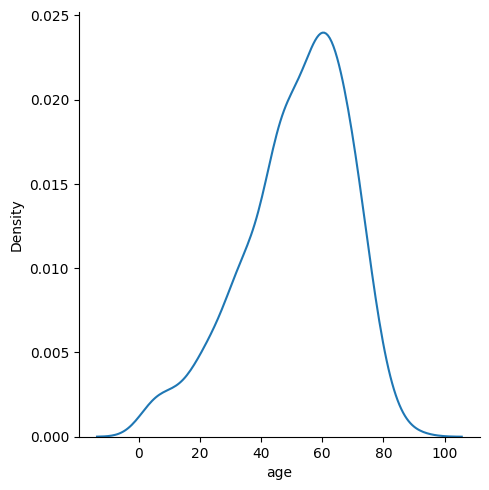

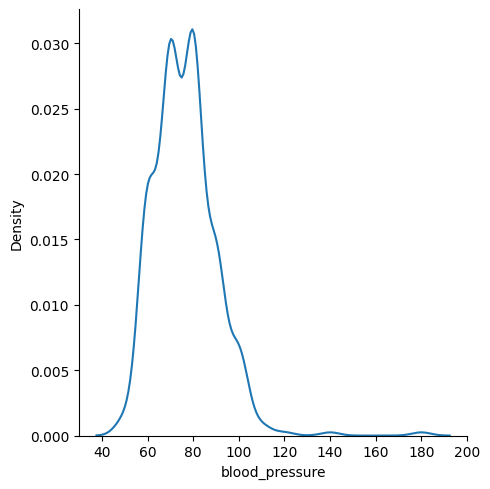

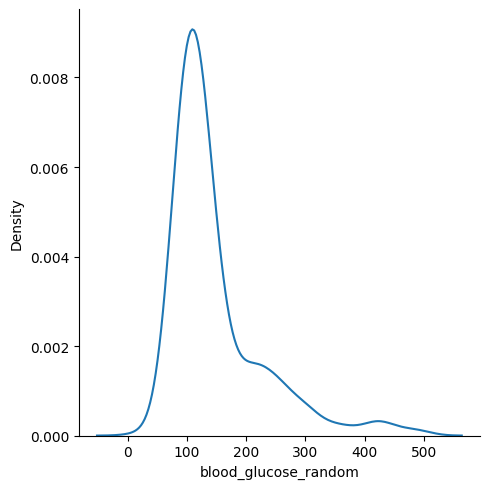

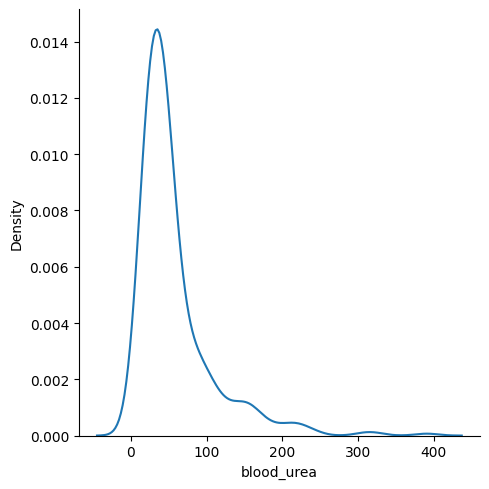

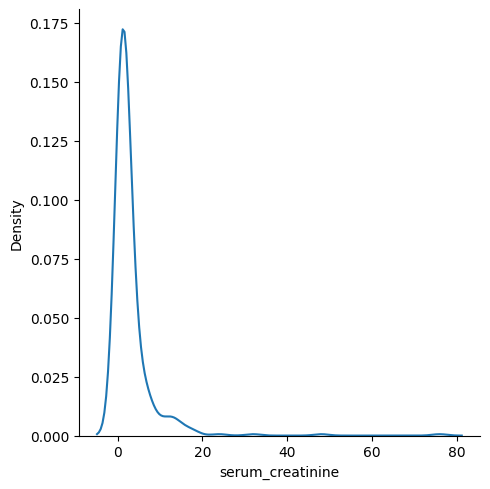

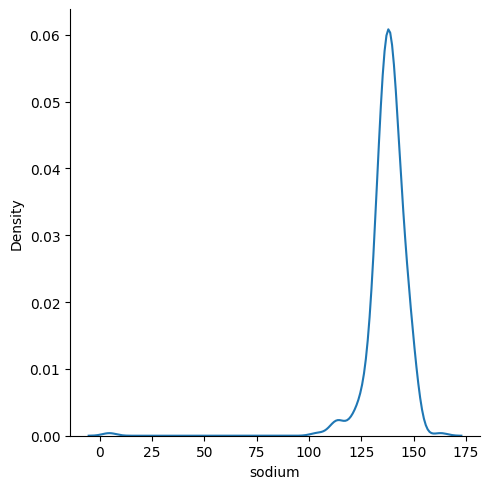

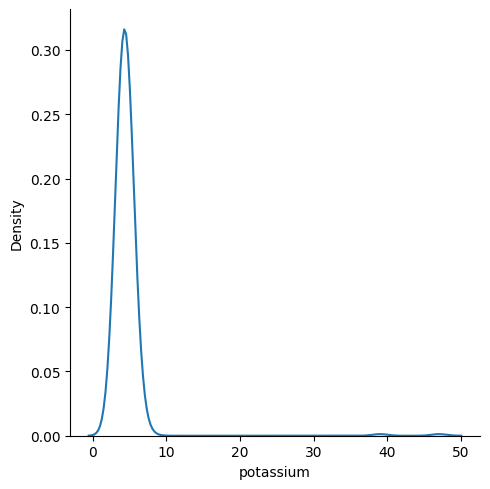

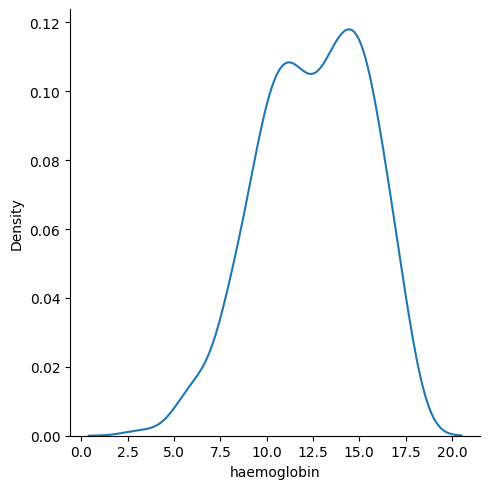

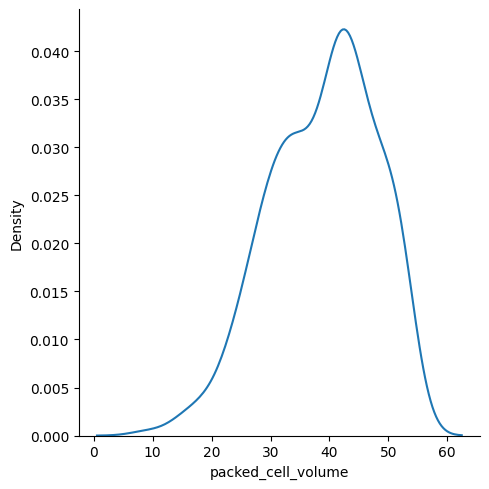

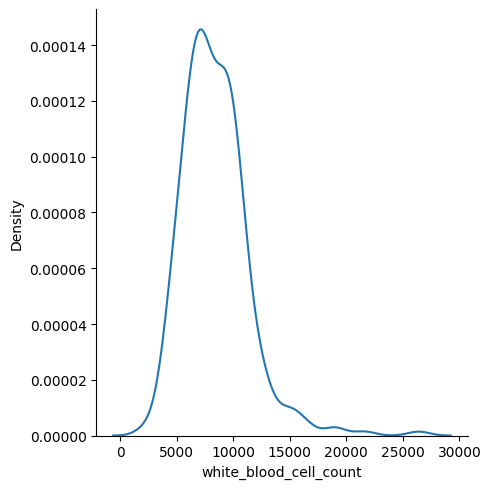

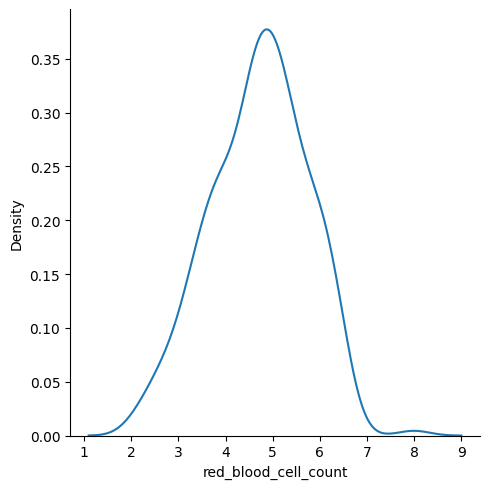

In [117]:
# checking numerical features distribution


plt.figure(figsize=(20,12))

# looping over num cols and checking its distribution
for col in num_cols:
 sns.displot(chronic_df[col],kind='kde')





In [118]:
# let's see the cols in cat col list
for col in cat_cols:
  print(f"{col}")



specific_gravity
albumin
sugar
red_blood_cells
pus_cell
pus_cell_clumps
bacteria
hypertension
diabetes_mellitus
coronary_artery_disease
appetite
peda_edema
aanemia
class


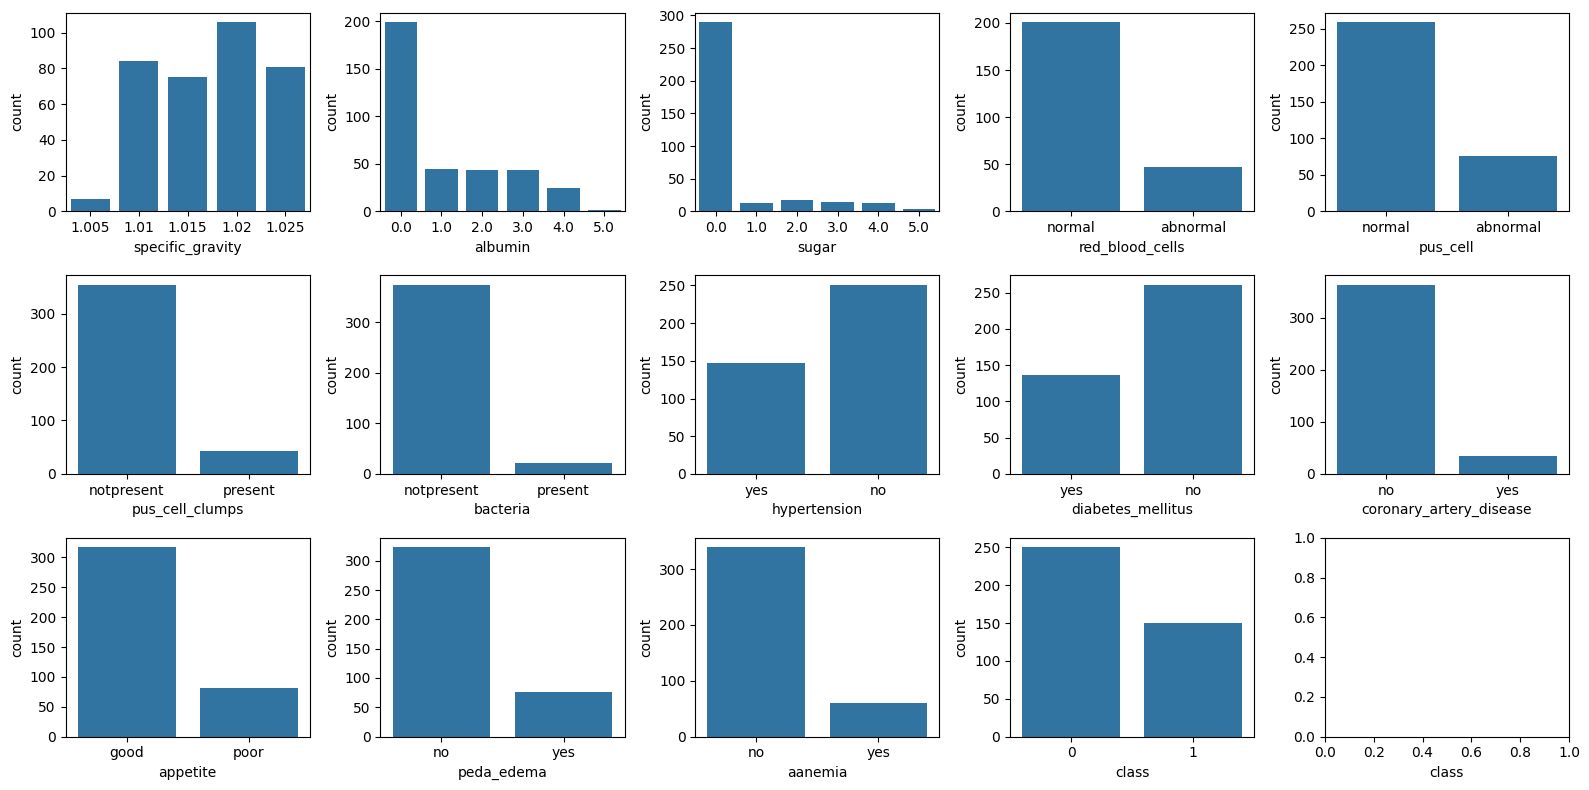

In [119]:
# checking cat features distribution

# create the figure and axes

fig, axes = plt.subplots(3, 5, figsize=(16,8))


axes = axes.ravel()  # flattening the array makes indexing easier

# loop over cat cols and plot countplot
for col,ax in zip(cat_cols,axes):
    sns.countplot(data=chronic_df, x=col, ax=ax)
    plt.xlabel(col)
    fig.tight_layout()







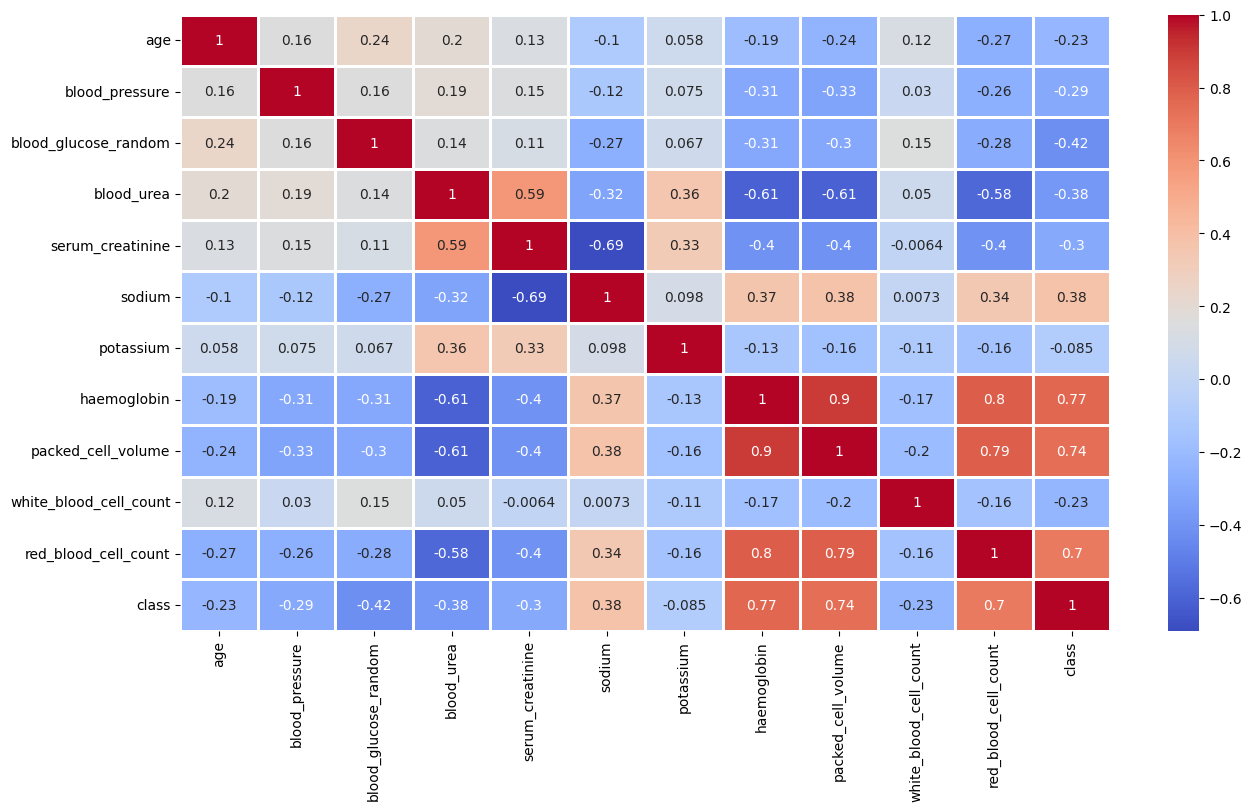

In [120]:
# correlated heatmap of data
numerical_df = chronic_df.select_dtypes(include=['int','float'])

plt.figure(figsize = (15, 8))
sns.heatmap(numerical_df.corr(), annot = True, cmap = 'coolwarm',linewidths=2)
plt.show()





In [121]:
# let's check count of null values in whole df

chronic_df.isnull().sum().sort_values(ascending = False)



,0
red_blood_cells,152
red_blood_cell_count,131
white_blood_cell_count,106
potassium,88
sodium,87
packed_cell_volume,71
pus_cell,65
haemoglobin,52
sugar,49
specific_gravity,47


In [122]:
# let's check count of null values in num_cols
chronic_df[num_cols].isnull().sum().sort_values(ascending = False)



,0
red_blood_cell_count,131
white_blood_cell_count,106
potassium,88
sodium,87
packed_cell_volume,71
haemoglobin,52
blood_glucose_random,44
blood_urea,19
serum_creatinine,17
blood_pressure,12


In [123]:
# let's check count of null values in cat cols
chronic_df[cat_cols].isnull().sum().sort_values(ascending = False)




,0
red_blood_cells,152
pus_cell,65
sugar,49
specific_gravity,47
albumin,46
pus_cell_clumps,4
bacteria,4
hypertension,2
diabetes_mellitus,2
coronary_artery_disease,2


## **`Missing Value Treatment`**

In [124]:
# filling null values, we will use two methods, random sampling for higher null values and
# mean/mode sampling for lower null values

# creating func for imputing random values
#def random_value_imputation(feature):
    #random_sample =chronic_df[feature].dropna().sample(chronic_df[feature].isnull().sum())
    #random_sample.index =chronic_df[chronic_df[feature].isnull()].index
    #chronic_df.loc[chronic_df[feature].isnull(), feature] =random_sample

# creating func for imputing most common value(modal value)
#def impute_mode(feature):
    #mode = chronic_df[feature].mode()[0]
    #chronic_df[feature] = chronic_df[feature].fillna(mode)

In [125]:
# filling num_cols null values using random sampling method
#for col in num_cols:
    #random_value_imputation(col)




In [126]:
# let's check count of null values in num_cols again
#chronic_df[num_cols].isnull().sum().sort_values(ascending = False)




In [127]:
# filling "red_blood_cells" and "pus_cell" using random sampling method and rest of cat_cols using mode imputation
#random_value_imputation('red_blood_cells')
#random_value_imputation('pus_cell')


#for col in cat_cols:
    #impute_mode(col)




In [128]:
# let's check count of null values in cat_cols again
#chronic_df[cat_cols].isnull().sum().sort_values(ascending = False)


In [129]:
# check unique values in each cat col by looping over cat cols
for col in cat_cols:
  print(f"{col} has {chronic_df[col].nunique()}values\n")






specific_gravity has 5values

albumin has 6values

sugar has 6values

red_blood_cells has 2values

pus_cell has 2values

pus_cell_clumps has 2values

bacteria has 2values

hypertension has 2values

diabetes_mellitus has 2values

coronary_artery_disease has 2values

appetite has 2values

peda_edema has 2values

aanemia has 2values

class has 2values



In [130]:
chronic_df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.02,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,0
1,7.0,50.0,1.02,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,0
2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,0
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,0
4,51.0,80.0,1.01,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,0


In [56]:
# using labelencoder and applying on cat cols
#from sklearn.preprocessing import LabelEncoder

#le = LabelEncoder()

#for col in cat_cols[3:]:
    #chronic_df[col] =le.fit_transform(chronic_df[col])

In [57]:
# check chronic df after transforming cat cols
#chronic_df.head()




,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,0,1,0,0,108.0,...,38.0,6000.0,5.9,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.3,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [131]:
# Split data into features and target variables (X and y)
X =chronic_df.drop('class', axis = 1)
y = chronic_df['class']




In [60]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle











In [133]:

# Define categorical & numeric columns again
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Final numeric cols   :", num_cols)
print("Final categorical cols:", cat_cols)

Final numeric cols   : Index(['age', 'blood_pressure', 'blood_glucose_random', 'blood_urea',
       'serum_creatinine', 'sodium', 'potassium', 'haemoglobin',
       'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count'],
      dtype='object')
Final categorical cols: Index(['specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
       'pus_cell_clumps', 'bacteria', 'hypertension', 'diabetes_mellitus',
       'coronary_artery_disease', 'appetite', 'peda_edema', 'aanemia'],
      dtype='object')


 **Preprocessor (Pipeline handles preprocessing)**

In [134]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ],
    remainder='drop'
)

## **`Model Building`**

In [135]:
models = {
    'knn'   : KNeighborsClassifier(),
    'dtc'   : DecisionTreeClassifier(random_state=42),
    'rd_clf': RandomForestClassifier(random_state=42),
    'ada'   : AdaBoostClassifier(random_state=42),
    'gb'    : GradientBoostingClassifier(random_state=42),
    'sgb'   : GradientBoostingClassifier(random_state=42, subsample=0.8),  # stochastic GB
    'etc'   : ExtraTreesClassifier(random_state=42),
}

list(models.keys())












['knn', 'dtc', 'rd_clf', 'ada', 'gb', 'sgb', 'etc']

**Train, evaluate, and save each model pipeline**

In [136]:
results = {}
trained_pipes = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', clf)])
    pipe.fit(X_train, y_train)

    y_pred_test  = pipe.predict(X_test)
    y_pred_train = pipe.predict(X_train)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test,  y_pred_test)

    print("="*60)
    print(f"Model: {name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test  Accuracy:  {test_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
    print("Classification Report:\n", classification_report(y_test, y_pred_test))

    results[name] = test_acc
    trained_pipes[name] = pipe

Model: knn
Train Accuracy: 0.8938
Test  Accuracy:  0.9500
Confusion Matrix:
 [[48  4]
 [ 0 28]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        52
           1       0.88      1.00      0.93        28

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80

Model: dtc
Train Accuracy: 1.0000
Test  Accuracy:  0.9500
Confusion Matrix:
 [[48  4]
 [ 0 28]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        52
           1       0.88      1.00      0.93        28

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80

Model: rd_clf
Train Accuracy: 1.0000
Test  Accuracy:  1.0000
Confusion Matrix:
 [[52  0]
 [ 0 28]]
Classif

# comparison table


In [137]:
pd.DataFrame(
    {'models': list(results.keys()), 'accuracy_scores': list(results.values())}
).sort_values(by='accuracy_scores', ascending=False)

,models,accuracy_scores
2,rd_clf,1.0000
4,gb,0.9875
3,ada,0.9875
5,sgb,0.9875
6,etc,0.9875
1,dtc,0.9500
0,knn,0.9500


In [139]:
# ================================
# 12) GridSearchCV — Decision Tree (pipeline)
# ================================
dt_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__splitter': ['best', 'random'],
    'classifier__min_samples_leaf': [1, 2, 3, 5, 7],
    'classifier__min_samples_split': [2, 3, 5, 7],   # must be >=2
    'classifier__max_features': [None, 'sqrt', 'log2']  # avoid 'auto'
}

gs = GridSearchCV(dt_pipe, param_grid, cv=5, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best Parameters:", gs.best_params_)
print("Best CV Score :", gs.best_score_)

best_dtc = gs.best_estimator_
y_pred = best_dtc.predict(X_test)
print("\nTuned Decision Tree")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))




Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__max_features': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 7, 'classifier__splitter': 'random'}
Best CV Score : 0.978125

Tuned Decision Tree
Test Accuracy: 0.9750
Confusion Matrix:
 [[52  0]
 [ 2 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        52
           1       1.00      0.93      0.96        28

    accuracy                           0.97        80
   macro avg       0.98      0.96      0.97        80
weighted avg       0.98      0.97      0.97        80



In [140]:
import pickle

# ✅ Final model pipeline (preprocessor + ExtraTrees)
from sklearn.ensemble import ExtraTreesClassifier

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', ExtraTreesClassifier(random_state=42))
])

# Fit on train data
final_model.fit(X_train, y_train)

# Save the pipeline (preprocessor + model together)
with open("final_extratrees_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ ExtraTrees model pipeline saved successfully!")


✅ ExtraTrees model pipeline saved successfully!


**prediction**

In [142]:
# Example new raw data with correct column names
new_data = pd.DataFrame({
    'age': [45],
    'blood_pressure': [80],
    'specific_gravity': [1.020],
    'albumin': [1],
    'sugar': [0],
    'red_blood_cells': ['normal'],
    'pus_cell': ['normal'],
    'pus_cell_clumps': ['notpresent'],
    'bacteria': ['notpresent'],
    'blood_glucose_random': [121],
    'blood_urea': [36],
    'serum_creatinine': [1.2],
    'sodium': [138],
    'potassium': [4.5],
    'haemoglobin': [15.2],
    'packed_cell_volume': [44],
    'white_blood_cell_count': [7800],
    'red_blood_cell_count': [5.2],
    'hypertension': ['no'],
    'diabetes_mellitus': ['no'],
    'coronary_artery_disease': ['no'],
    'appetite': ['good'],
    'peda_edema': ['no'],
    'aanemia': ['no']
})

# Predict using pipeline
prediction = final_model.predict(new_data)[0]

if prediction == 1:
    print("⚠️ The patient HAS Chronic Kidney Disease.")
else:
    print("✅ The patient does NOT have Chronic Kidney Disease.")


✅ The patient does NOT have Chronic Kidney Disease.
